<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  9.18MB/s    in 17s     

2026-05-21 04:26:14 (8.75 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


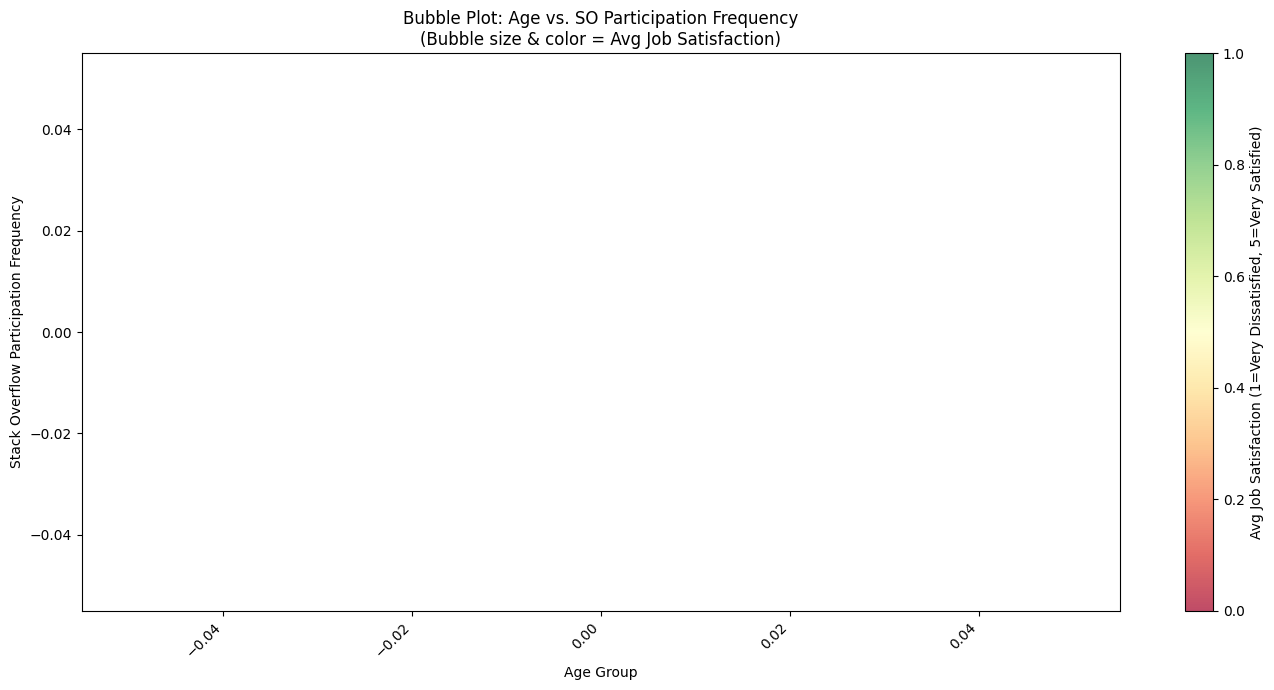

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select and clean relevant columns
df_clean = df[['Age', 'SOPartFreq', 'JobSat']].dropna()

# Map JobSat to numeric bubble sizes
jobsat_map = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}
df_clean = df_clean.copy()
df_clean['JobSat_num'] = df_clean['JobSat'].map(jobsat_map)
df_clean = df_clean.dropna(subset=['JobSat_num'])

# Aggregate: count respondents per (Age, SOPartFreq) group, avg JobSat
agg = (
    df_clean
    .groupby(['Age', 'SOPartFreq'])
    .agg(count=('JobSat_num', 'size'), avg_jobsat=('JobSat_num', 'mean'))
    .reset_index()
)

# Bubble size scaled by avg JobSat
bubble_size = agg['avg_jobsat'] * 100

# Plot
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    agg['Age'],
    agg['SOPartFreq'],
    s=bubble_size,
    c=agg['avg_jobsat'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Avg Job Satisfaction (1=Very Dissatisfied, 5=Very Satisfied)')
plt.xlabel('Age Group')
plt.ylabel('Stack Overflow Participation Frequency')
plt.title('Bubble Plot: Age vs. SO Participation Frequency\n(Bubble size & color = Avg Job Satisfaction)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


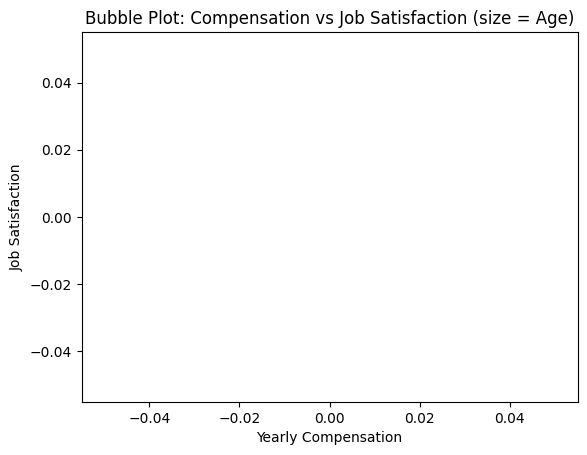

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select relevant columns and clean data
df_clean = df[['ConvertedCompYearly', 'JobSat', 'Age']].dropna()

# Ensure numeric types
df_clean['ConvertedCompYearly'] = pd.to_numeric(df_clean['ConvertedCompYearly'], errors='coerce')
df_clean['JobSat'] = pd.to_numeric(df_clean['JobSat'], errors='coerce')
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

# Drop rows with failed conversions
df_clean = df_clean.dropna()

# Bubble size (scale Age for visibility)
bubble_size = df_clean['Age'] * 5

# Plot
plt.figure()
plt.scatter(
    df_clean['ConvertedCompYearly'],
    df_clean['JobSat'],
    s=bubble_size,
    alpha=0.5
)

# Labels
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.title("Bubble Plot: Compensation vs Job Satisfaction (size = Age)")

plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



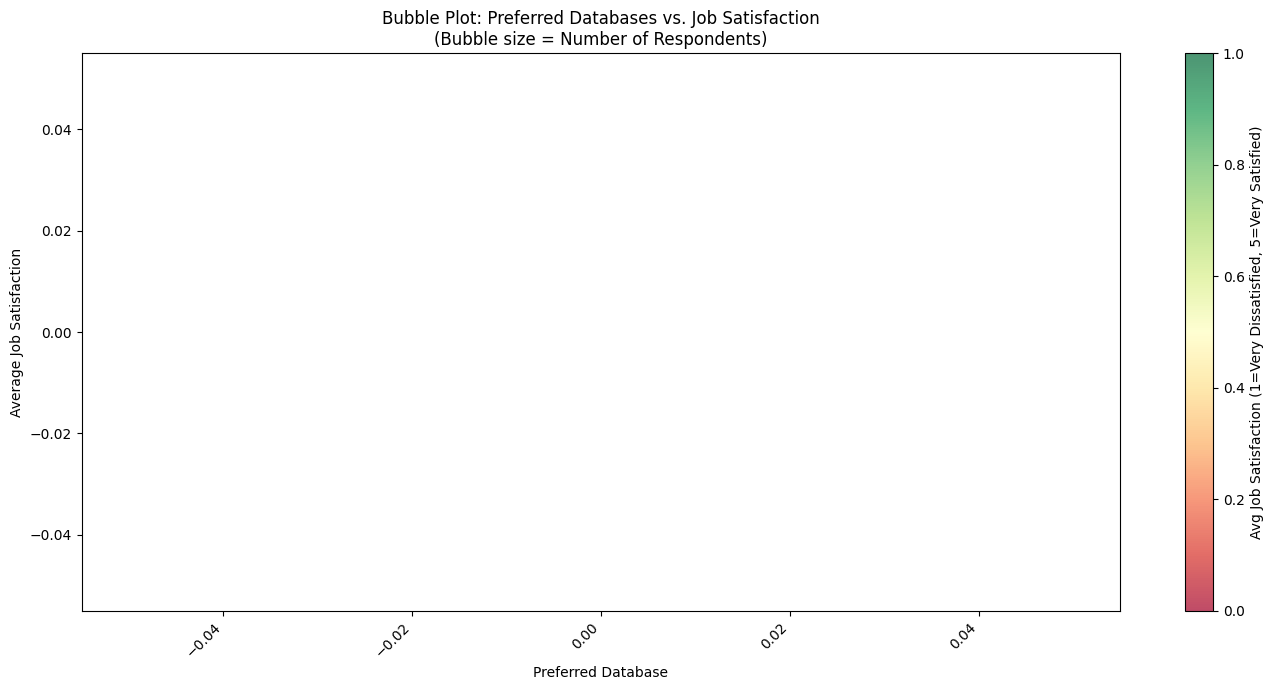

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select relevant columns
df_clean = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Map JobSat to numeric
jobsat_map = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}
df_clean = df_clean.copy()
df_clean['JobSat_num'] = df_clean['JobSat'].map(jobsat_map)
df_clean = df_clean.dropna(subset=['JobSat_num'])

# Split multi-value DatabaseWantToWorkWith column and explode
df_clean['DatabaseWantToWorkWith'] = df_clean['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('DatabaseWantToWorkWith')
df_exploded['DatabaseWantToWorkWith'] = df_exploded['DatabaseWantToWorkWith'].str.strip()
df_exploded = df_exploded[df_exploded['DatabaseWantToWorkWith'] != '']

# Aggregate: avg JobSat and count per database
agg = (
    df_exploded
    .groupby('DatabaseWantToWorkWith')
    .agg(avg_jobsat=('JobSat_num', 'mean'), count=('JobSat_num', 'size'))
    .reset_index()
)

# Keep top 15 databases by respondent count
agg = agg.nlargest(15, 'count')

# Bubble size scaled by respondent count
bubble_size = agg['count'] / agg['count'].max() * 3000

# Plot
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    agg['DatabaseWantToWorkWith'],
    agg['avg_jobsat'],
    s=bubble_size,
    c=agg['avg_jobsat'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Avg Job Satisfaction (1=Very Dissatisfied, 5=Very Satisfied)')
plt.xlabel('Preferred Database')
plt.ylabel('Average Job Satisfaction')
plt.title('Bubble Plot: Preferred Databases vs. Job Satisfaction\n(Bubble size = Number of Respondents)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


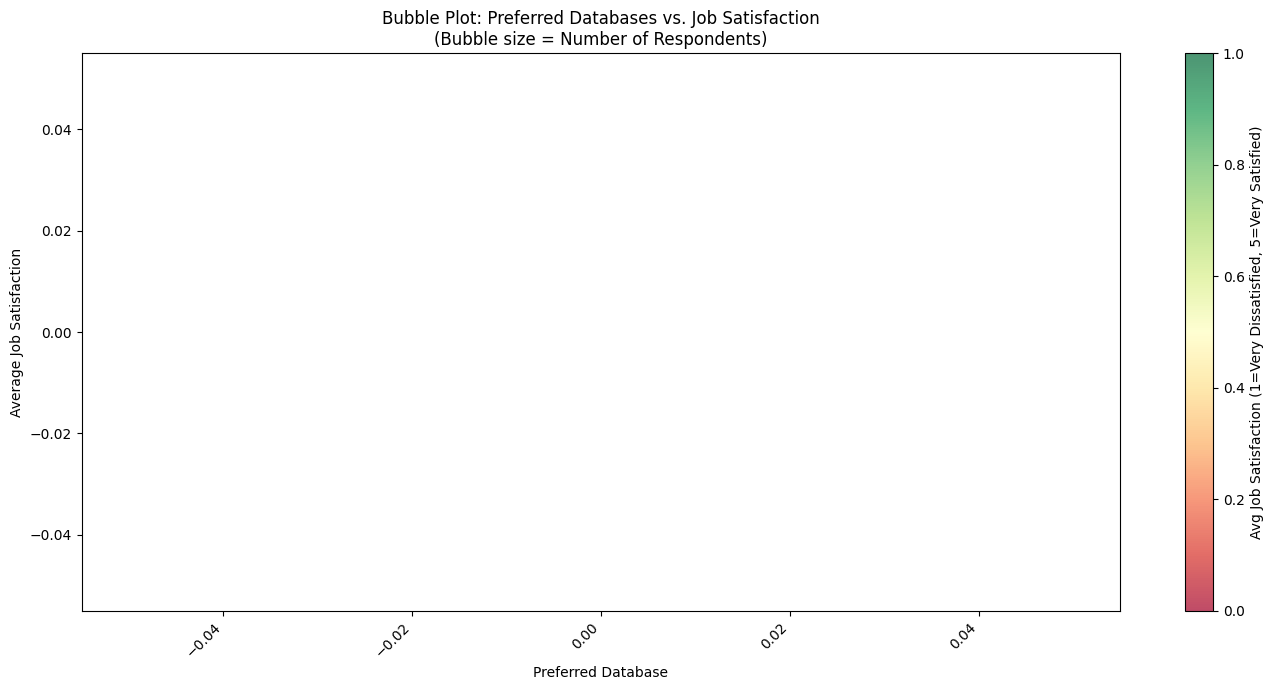

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select relevant columns and drop nulls
df_clean = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Map JobSat to numeric values
jobsat_map = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}
df_clean = df_clean.copy()
df_clean['JobSat_num'] = df_clean['JobSat'].map(jobsat_map)
df_clean = df_clean.dropna(subset=['JobSat_num'])

# Split multi-value column and explode
df_clean['DatabaseWantToWorkWith'] = df_clean['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('DatabaseWantToWorkWith')
df_exploded['DatabaseWantToWorkWith'] = df_exploded['DatabaseWantToWorkWith'].str.strip()
df_exploded = df_exploded[df_exploded['DatabaseWantToWorkWith'] != '']

# Aggregate: avg JobSat and count per database
agg = (
    df_exploded
    .groupby('DatabaseWantToWorkWith')
    .agg(avg_jobsat=('JobSat_num', 'mean'), count=('JobSat_num', 'size'))
    .reset_index()
)

# Keep top 15 databases by respondent count
agg = agg.nlargest(15, 'count')

# Bubble size scaled by respondent count
bubble_size = agg['count'] / agg['count'].max() * 3000

# Plot
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    agg['DatabaseWantToWorkWith'],
    agg['avg_jobsat'],
    s=bubble_size,
    c=agg['avg_jobsat'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Avg Job Satisfaction (1=Very Dissatisfied, 5=Very Satisfied)')
plt.xlabel('Preferred Database')
plt.ylabel('Average Job Satisfaction')
plt.title('Bubble Plot: Preferred Databases vs. Job Satisfaction\n(Bubble size = Number of Respondents)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


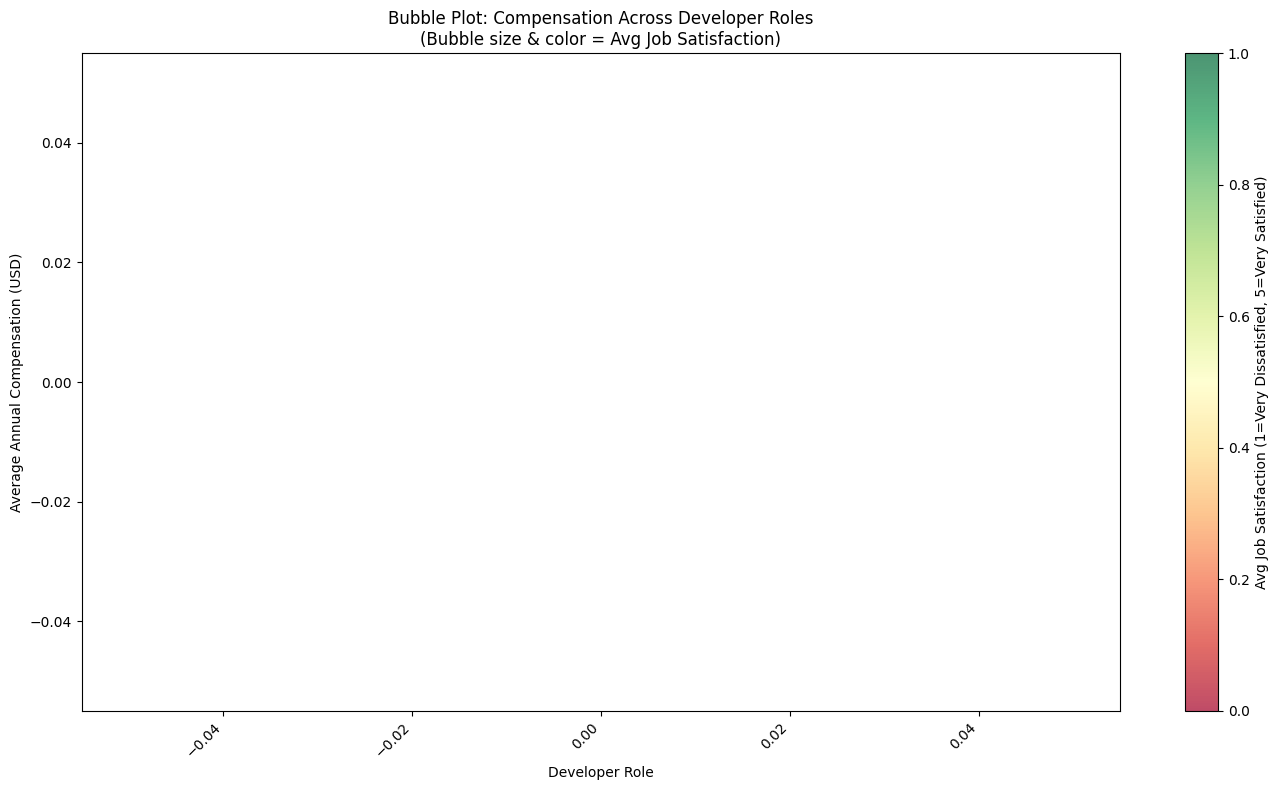

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select relevant columns and drop nulls
df_clean = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()

# Map JobSat to numeric values
jobsat_map = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}
df_clean = df_clean.copy()
df_clean['JobSat_num'] = df_clean['JobSat'].map(jobsat_map)
df_clean = df_clean.dropna(subset=['JobSat_num'])

# Split multi-value DevType column and explode
df_clean['DevType'] = df_clean['DevType'].str.split(';')
df_exploded = df_clean.explode('DevType')
df_exploded['DevType'] = df_exploded['DevType'].str.strip()
df_exploded = df_exploded[df_exploded['DevType'] != '']

# Remove extreme salary outliers
df_exploded = df_exploded[df_exploded['ConvertedCompYearly'] < 500000]

# Aggregate: avg compensation, avg job satisfaction, and count per DevType
agg = (
    df_exploded
    .groupby('DevType')
    .agg(
        avg_comp=('ConvertedCompYearly', 'mean'),
        avg_jobsat=('JobSat_num', 'mean'),
        count=('JobSat_num', 'size')
    )
    .reset_index()
)

# Keep top 15 roles by respondent count
agg = agg.nlargest(15, 'count')

# Bubble size scaled by avg job satisfaction
bubble_size = agg['avg_jobsat'] * 300

# Plot
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    agg['DevType'],
    agg['avg_comp'],
    s=bubble_size,
    c=agg['avg_jobsat'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Avg Job Satisfaction (1=Very Dissatisfied, 5=Very Satisfied)')
plt.xlabel('Developer Role')
plt.ylabel('Average Annual Compensation (USD)')
plt.title('Bubble Plot: Compensation Across Developer Roles\n(Bubble size & color = Avg Job Satisfaction)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


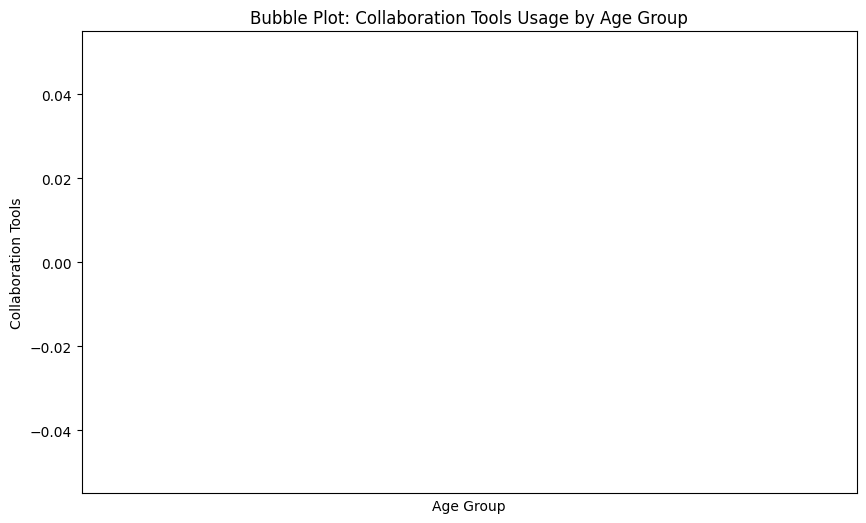

In [20]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select relevant columns
df_clean = df[['Age', 'NEWCollabToolsHaveWorkedWith']].copy()

# Clean data (avoid aggressive dropna)
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

df_clean = df_clean[
    df_clean['Age'].notna() &
    df_clean['NEWCollabToolsHaveWorkedWith'].notna() &
    (df_clean['NEWCollabToolsHaveWorkedWith'] != '')
]

# Split multi-value column
df_clean['NEWCollabToolsHaveWorkedWith'] = df_clean['NEWCollabToolsHaveWorkedWith'].str.split(';')

# Explode into rows
df_exploded = df_clean.explode('NEWCollabToolsHaveWorkedWith')

# Create age groups
df_exploded['AgeGroup'] = pd.cut(
    df_exploded['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+']
)

# Count frequency
freq = (
    df_exploded
    .groupby(['AgeGroup', 'NEWCollabToolsHaveWorkedWith'])
    .size()
    .reset_index(name='Count')
)

# Keep top tools (important or chart becomes unreadable)
top_tools = (
    freq.groupby('NEWCollabToolsHaveWorkedWith')['Count']
    .sum()
    .nlargest(10)
    .index
)

freq = freq[freq['NEWCollabToolsHaveWorkedWith'].isin(top_tools)]

# Convert AgeGroup to numeric for plotting
age_map = {label: i for i, label in enumerate(freq['AgeGroup'].unique())}
freq['AgeGroup_num'] = freq['AgeGroup'].map(age_map)

# Bubble size
bubble_size = freq['Count'] * 2

# Plot
plt.figure(figsize=(10,6))
plt.scatter(
    freq['AgeGroup_num'],
    freq['NEWCollabToolsHaveWorkedWith'],
    s=bubble_size,
    alpha=0.6
)

# Labels
plt.xlabel("Age Group")
plt.ylabel("Collaboration Tools")
plt.title("Bubble Plot: Collaboration Tools Usage by Age Group")

plt.xticks(list(age_map.values()), list(age_map.keys()), rotation=30)

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



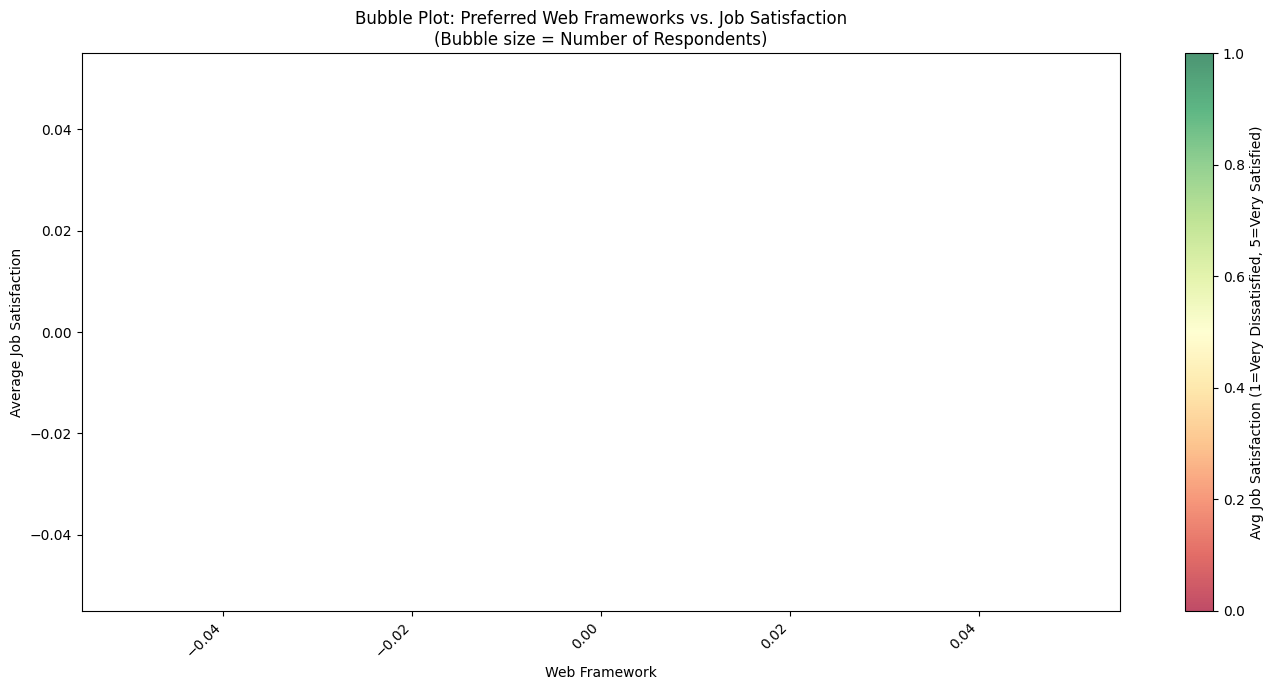

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select and clean relevant columns
df_clean = df[['WebframeWantToWorkWith', 'JobSat']].dropna()
df_clean = df_clean[df_clean['WebframeWantToWorkWith'] != '']

# Map JobSat to numeric
jobsat_map = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}
df_clean = df_clean.copy()
df_clean['JobSat_num'] = df_clean['JobSat'].map(jobsat_map)
df_clean = df_clean.dropna(subset=['JobSat_num'])

# Split multi-value column and explode
df_clean['WebframeWantToWorkWith'] = df_clean['WebframeWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('WebframeWantToWorkWith')
df_exploded['WebframeWantToWorkWith'] = df_exploded['WebframeWantToWorkWith'].str.strip()
df_exploded = df_exploded[df_exploded['WebframeWantToWorkWith'] != '']

# Aggregate: avg JobSat and count per framework
agg = (
    df_exploded
    .groupby('WebframeWantToWorkWith')
    .agg(avg_jobsat=('JobSat_num', 'mean'), count=('JobSat_num', 'size'))
    .reset_index()
)

# Top 15 by respondent count
agg = agg.nlargest(15, 'count')

# Bubble size scaled by respondent count
bubble_size = agg['count'] / agg['count'].max() * 3000

# Plot
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    agg['WebframeWantToWorkWith'],
    agg['avg_jobsat'],
    s=bubble_size,
    c=agg['avg_jobsat'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Avg Job Satisfaction (1=Very Dissatisfied, 5=Very Satisfied)')
plt.xlabel('Web Framework')
plt.ylabel('Average Job Satisfaction')
plt.title('Bubble Plot: Preferred Web Frameworks vs. Job Satisfaction\n(Bubble size = Number of Respondents)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



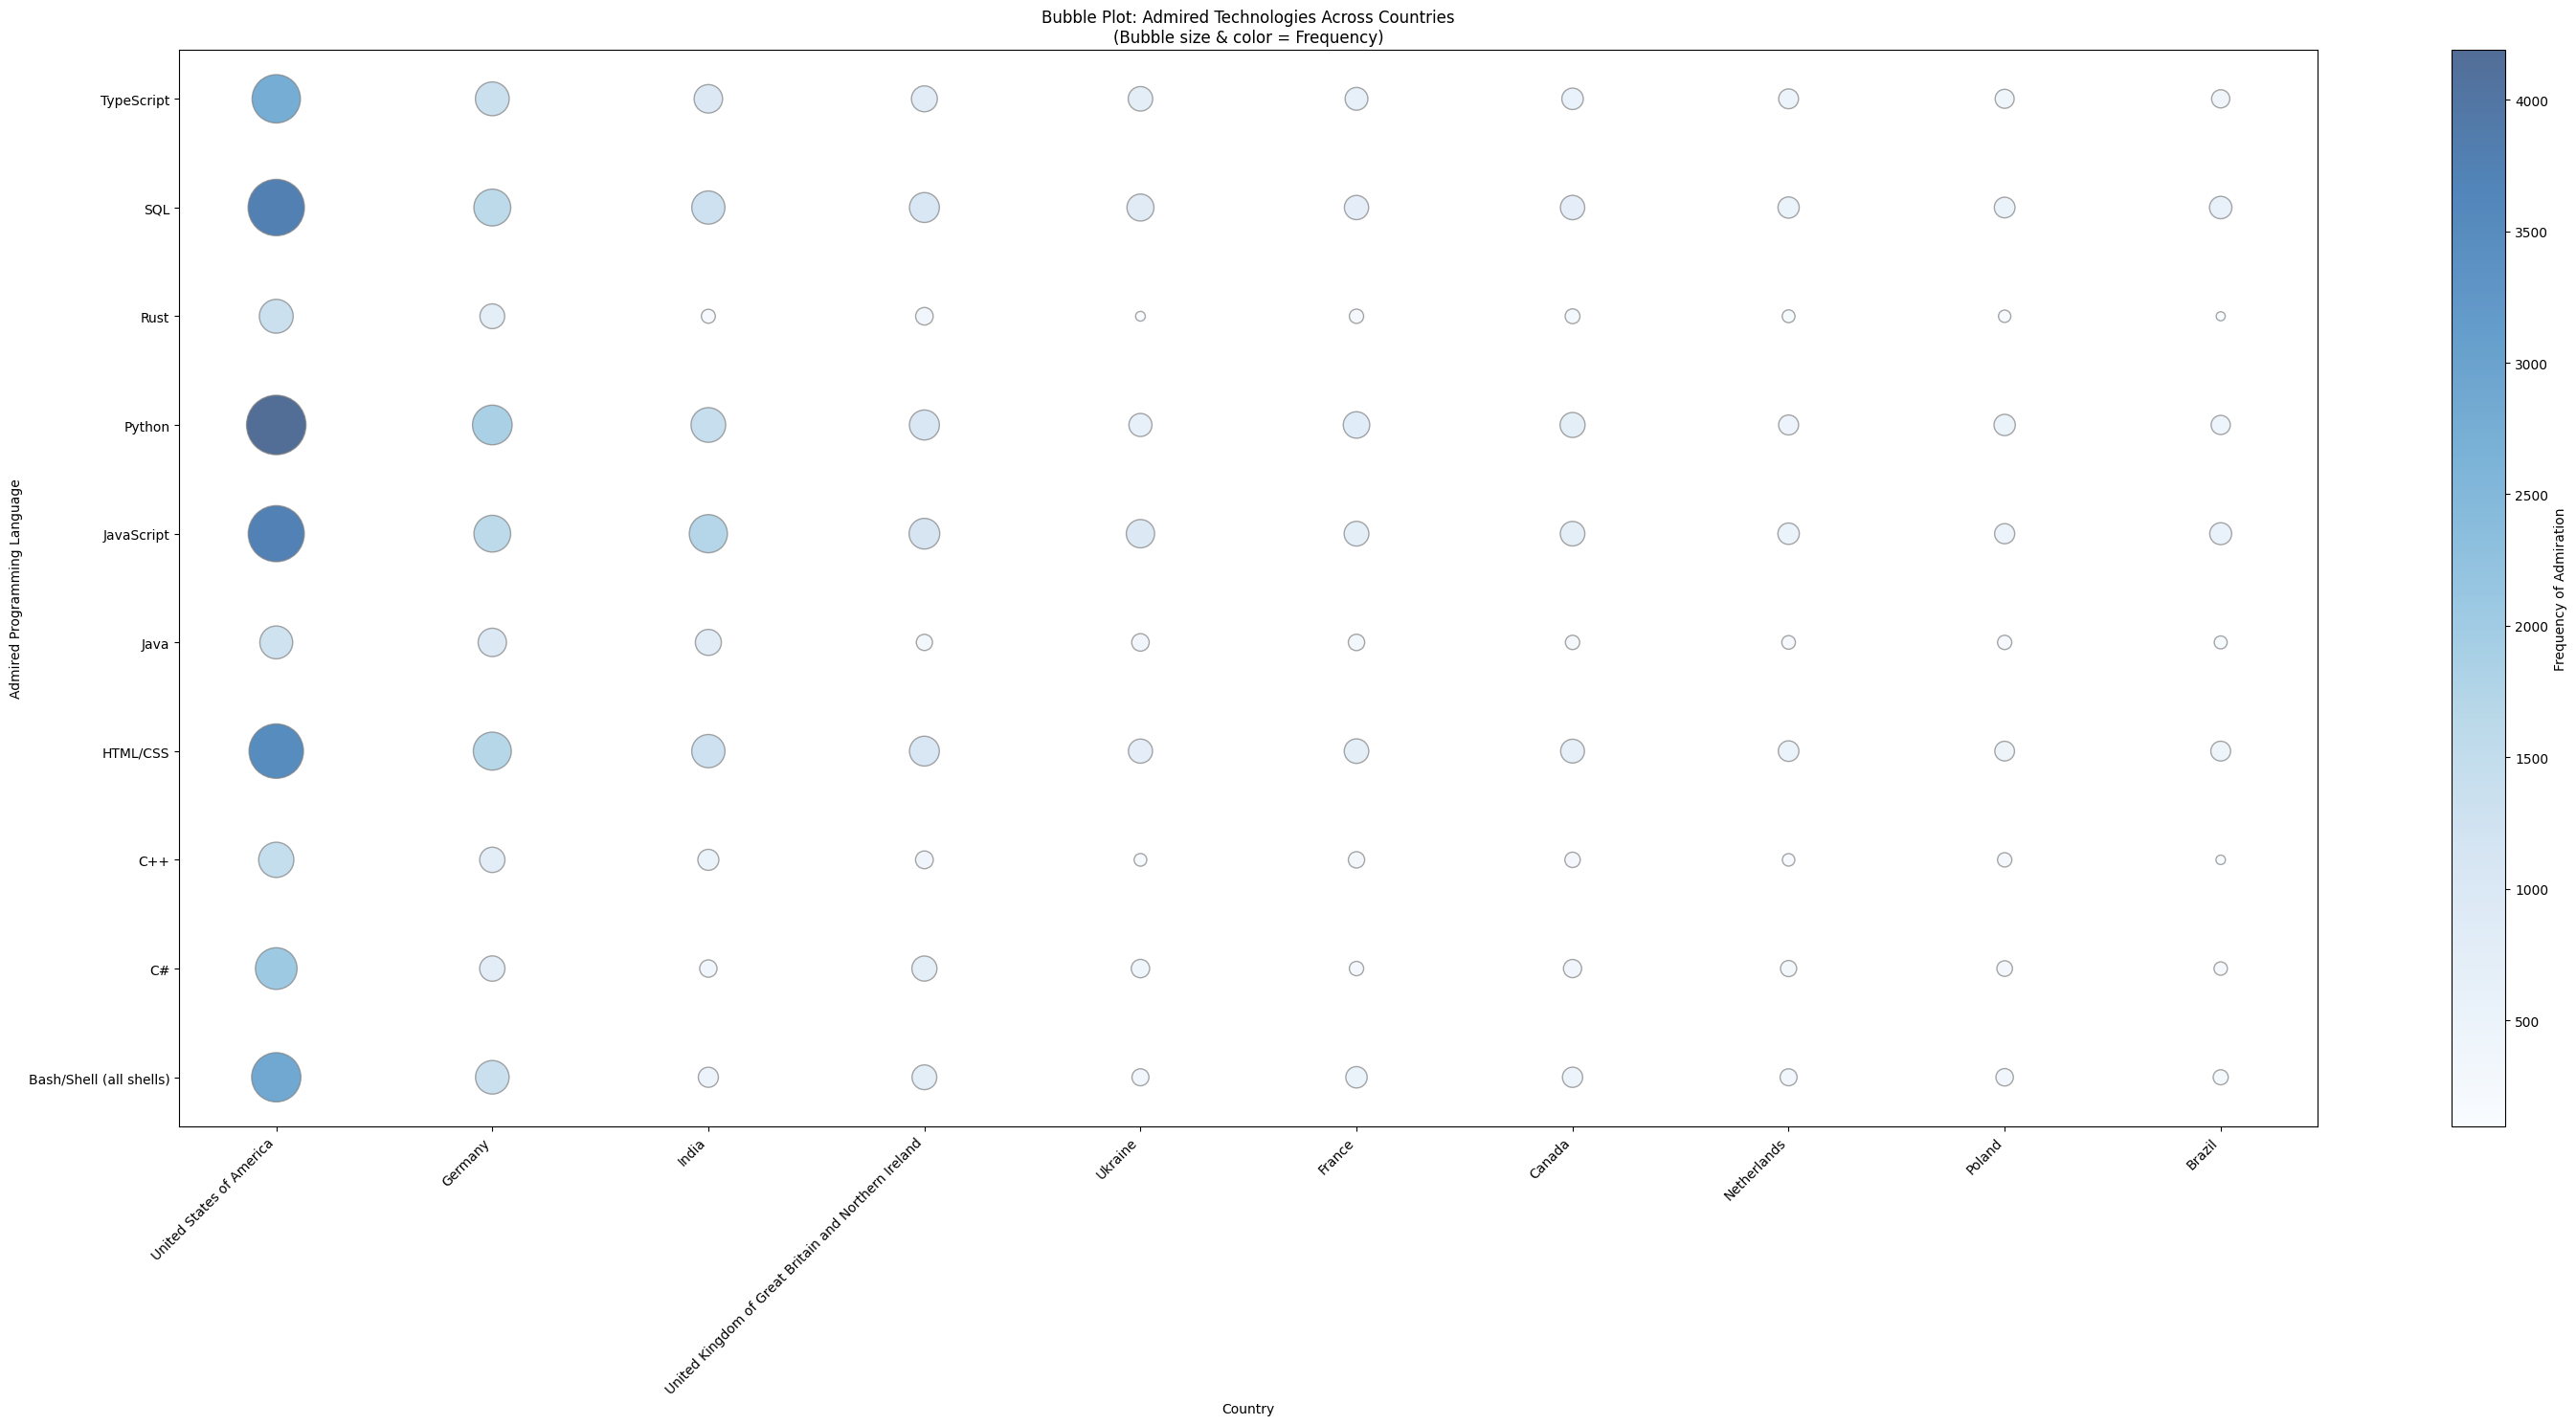

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("survey-data.csv")

# Select and clean relevant columns
df_clean = df[['Country', 'LanguageAdmired']].dropna()
df_clean = df_clean[df_clean['LanguageAdmired'] != '']

# Split multi-value column and explode
df_clean = df_clean.copy()
df_clean['LanguageAdmired'] = df_clean['LanguageAdmired'].str.split(';')
df_exploded = df_clean.explode('LanguageAdmired')
df_exploded['LanguageAdmired'] = df_exploded['LanguageAdmired'].str.strip()
df_exploded = df_exploded[df_exploded['LanguageAdmired'] != '']

# Aggregate frequency per (Country, Language)
freq = (
    df_exploded
    .groupby(['Country', 'LanguageAdmired'])
    .size()
    .reset_index(name='Count')
)

# Top 10 countries and top 10 languages for readability
top_countries = freq.groupby('Country')['Count'].sum().nlargest(10).index
top_langs = freq.groupby('LanguageAdmired')['Count'].sum().nlargest(10).index

freq = freq[freq['Country'].isin(top_countries) & freq['LanguageAdmired'].isin(top_langs)]

# Map countries to numeric positions for x-axis
country_order = freq.groupby('Country')['Count'].sum().sort_values(ascending=False).index.tolist()
country_map = {c: i for i, c in enumerate(country_order)}
freq['Country_num'] = freq['Country'].map(country_map)

# Bubble size scaled by count
bubble_size = freq['Count'] / freq['Count'].max() * 2000

# Plot
plt.figure(figsize=(30, 15))
scatter = plt.scatter(
    freq['Country_num'],
    freq['LanguageAdmired'],
    s=bubble_size,
    c=freq['Count'],
    cmap='Blues',
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Frequency of Admiration')
plt.xlabel('Country')
plt.ylabel('Admired Programming Language')
plt.title('Bubble Plot: Admired Technologies Across Countries\n(Bubble size & color = Frequency)')
plt.xticks(list(country_map.values()), list(country_map.keys()), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
